# Graph neural networks

## Why graphs?

Many data sets are naturally structured as a *graph* $G = (V, E)$ of nodes $V$ connected by edges $E$, rather than as a table of independent feature vectors. This is especially relevant in biology and chemistry: molecules are graphs of atoms (nodes) connected by bonds (edges), and the same topology-based representation applies to protein–protein interaction networks, metabolic networks, and knowledge graphs in biomedicine. A graph neural network (GNN) learns node representations that take this connectivity into account, by repeatedly mixing each node's features with those of its neighbors.

## Components and structure

As in the basic neural network notebook, every node $n$ has a feature vector at layer $L$, here written $\boldsymbol{h}_n^{(L)}$. Instead of a single dense weight matrix connecting *all* neurons of one layer to the next, a GNN layer only mixes a node's features with those of its graph neighbors $\mathcal{N}(n)$.

The graph connectivity is stored in the adjacency matrix $\boldsymbol{A}$ ($A_{ij}=1$ if nodes $i$ and $j$ are connected) and the degree matrix $\boldsymbol{D}$ (diagonal, $D_{ii}$ = number of neighbors of node $i$). A widely used layer, the graph convolutional network (GCN) propagation rule, reads

$$
\boldsymbol{H}^{(L)} = f\!\left( \tilde{\boldsymbol{D}}^{-1/2} \tilde{\boldsymbol{A}} \, \tilde{\boldsymbol{D}}^{-1/2} \, \boldsymbol{H}^{(L-1)} \boldsymbol{W}^{(L)} \right)
$$

(1)

where $\tilde{\boldsymbol{A}} = \boldsymbol{A} + \boldsymbol{I}$ adds a self-loop to every node (so a node also retains its own information), $\tilde{\boldsymbol{D}}$ is the corresponding degree matrix, $\boldsymbol{W}^{(L)}$ is a (shared, learnable) weight matrix, and $f$ is a nonlinear activation. You can think of this as $\tilde{\boldsymbol{D}}^{-1/2} \tilde{\boldsymbol{A}} \tilde{\boldsymbol{D}}^{-1/2}$ representing a kernel, leading to a similar convolution or rather cross-correlation layer as already seen in the CNN notebook. Stacking $K$ such layers lets information flow $K$ hops away from each node — this is called *message passing*.

## Training the weight matrices

The weight matrices $\boldsymbol{W}^{(L)}$ are learned by minimizing a loss function with gradient descent, exactly as in the basic neural network notebook. For binary node classification with labels $y_i \in \{0,1\}$ we use the binary cross-entropy loss restricted to the training nodes,

$$
\mathcal{L} = -\frac{1}{|\mathcal{T}|}\sum_{i \in \mathcal{T}} \Big[ y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i) \Big]
$$

(2)

Because $\boldsymbol{A}_\mathrm{norm}$ is fixed and symmetric, backpropagating through each GCN layer (Eq. (1)) simply involves multiplying the incoming gradient by $\boldsymbol{A}_\mathrm{norm}$ and $\boldsymbol{W}^{(L)\top}$ — exactly as for an ordinary dense layer, with one extra fixed matrix multiplication.


## Library imports

In [47]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import sklearn


## Data preparation

We use Zachary's karate club graph: 34 members of a university karate club, split into two factions (node attribute `club`) after a conflict. This is a standard toy benchmark for GNNs, and the problem is entirely analogous to classifying nodes in any small biological network where community membership is the target (e.g. assigning proteins to functional modules in an interaction network).

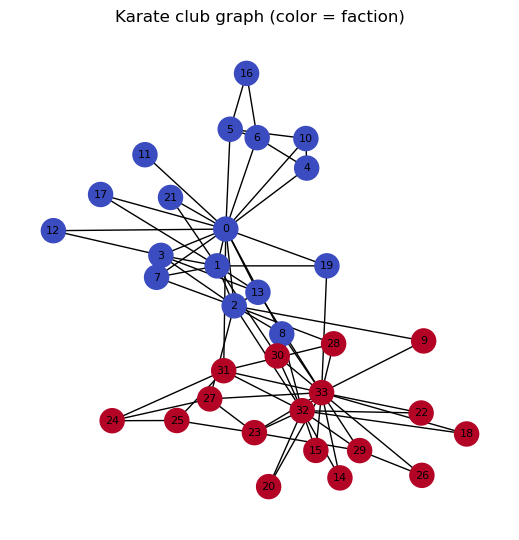

In [48]:
G = nx.karate_club_graph()
nodes = list(G.nodes())
n_nodes = G.number_of_nodes()

y = np.array([0 if G.nodes[n]["club"] == "Mr. Hi" else 1 for n in nodes])

pos = nx.spring_layout(G, seed=0)
plt.figure(figsize=(5, 5))
nx.draw(G, pos, node_color=y, cmap=plt.cm.coolwarm,
        with_labels=True, node_size=300, font_size=8)
plt.title("Karate club graph (color = faction)")
plt.show()


## Initial node features and graph normalization

When no node attributes are available, a standard choice is to start each node from its own one-hot indicator (the $N \times N$ identity matrix). The propagation rule of Eq. (1) then turns pure structural connectivity into informative lower-dimensional embeddings.

We also pre-compute the normalized adjacency matrix $\boldsymbol{A}_\mathrm{norm}$ once, since it does not change during training.

In [49]:
H0 = np.eye(n_nodes).astype(float)

A = nx.to_numpy_array(G)
A_tilde = A + np.eye(n_nodes)
D_inv_sqrt = np.diag(1.0 / np.sqrt(A_tilde.sum(axis=1)))
A_norm = D_inv_sqrt @ A_tilde @ D_inv_sqrt


## Train / test split

In [50]:
train_idx, test_idx = sklearn.model_selection.train_test_split(
    np.arange(n_nodes), test_size=0.25, stratify=y, random_state=0,
)
train_mask = np.zeros(n_nodes, dtype=bool)
train_mask[train_idx] = True


## Model definition

We implement a 2-layer GCN: two propagation layers (Eq. (1)) with ReLU activations, followed by a linear readout and a sigmoid to produce node-level class probabilities.

In [51]:
def relu(x):       return np.maximum(0.0, x)
def relu_grad(x):  return (x > 0.0).astype(float)
def sigmoid(x):    return 1.0 / (1.0 + np.exp(-x))

def init_weights(fan_in, fan_out, rng):
    return rng.normal(scale=np.sqrt(2.0 / fan_in), size=(fan_in, fan_out))

rng_w = np.random.default_rng(0)
W1 = init_weights(n_nodes, 8, rng_w)
W2 = init_weights(8, 4, rng_w)
W3 = init_weights(4, 1, rng_w)
b3 = np.zeros(1)


In [52]:
def forward(H0):
    Z1 = A_norm @ H0 @ W1
    H1 = relu(Z1)
    Z2 = A_norm @ H1 @ W2
    H2 = relu(Z2)
    logits = H2 @ W3 + b3        # shape (N, 1)
    y_hat = sigmoid(logits).ravel()
    return y_hat, (H0, Z1, H1, Z2, H2)

def backward(y_true, y_hat, cache, mask):
    H0, Z1, H1, Z2, H2 = cache
    n_train = mask.sum()
    # gradient of cross-entropy loss w.r.t. logits, zeroed for non-training nodes
    dlogits = np.zeros((n_nodes, 1))
    dlogits[mask, 0] = (y_hat[mask] - y_true[mask]) / n_train
    # readout layer
    dW3 = H2.T @ dlogits
    db3 = dlogits.sum(axis=0)
    # layer 2: Z2 = A_norm @ H1 @ W2
    dH2  = dlogits @ W3.T
    dZ2  = dH2 * relu_grad(Z2)
    dW2  = (A_norm @ H1).T @ dZ2
    dH1  = A_norm @ dZ2 @ W2.T      # A_norm is symmetric
    # layer 1: Z1 = A_norm @ H0 @ W1
    dZ1  = dH1 * relu_grad(Z1)
    dW1  = (A_norm @ H0).T @ dZ1
    return dW1, dW2, dW3, db3


## Model training

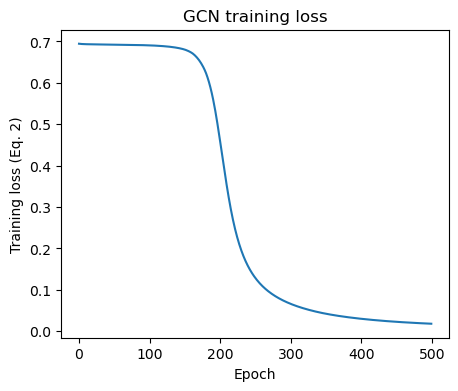

In [53]:
lr      = 0.5
n_epochs = 500
losses  = []
eps     = 1e-9

for epoch in range(n_epochs):
    y_hat, cache = forward(H0)
    loss = -np.mean(
        y[train_mask] * np.log(y_hat[train_mask] + eps)
        + (1 - y[train_mask]) * np.log(1 - y_hat[train_mask] + eps)
    )
    losses.append(loss)
    dW1, dW2, dW3, db3_ = backward(y, y_hat, cache, train_mask)
    W1 -= lr * dW1
    W2 -= lr * dW2
    W3 -= lr * dW3
    b3 -= lr * db3_

plt.figure(figsize=(5, 4))
plt.plot(losses)
plt.xlabel("Epoch"); plt.ylabel("Training loss (Eq. 2)")
plt.title("GCN training loss")
plt.show()


## Model evaluation

In [54]:
y_hat_final, _ = forward(H0)
y_pred = (y_hat_final > 0.5).astype(int)

print(sklearn.metrics.classification_report(
    y[test_idx], y_pred[test_idx],
    target_names=["Mr. Hi", "Officer"],
))


              precision    recall  f1-score   support

      Mr. Hi       1.00      1.00      1.00         5
     Officer       1.00      1.00      1.00         4

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



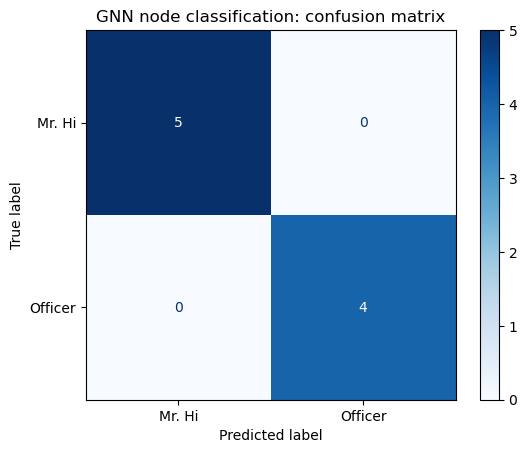

In [55]:
cm = sklearn.metrics.confusion_matrix(y[test_idx], y_pred[test_idx])
disp = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix=cm,
                                               display_labels=["Mr. Hi", "Officer"])
disp.plot(cmap=plt.cm.Blues)
plt.title("GNN node classification: confusion matrix")
plt.show()


## Cross-validation and model selection

The learning rate, number of epochs, and hidden layer sizes above were fixed by hand. As discussed in detail in the CNN notebook, these should be tuned by cross-validation; for a hand-written training loop `sklearn.model_selection.KFold` can still generate the node-index splits for each fold, even though the gradient descent loop is custom code.

## Take-away

In this notebook the weight matrices $\boldsymbol{W}^{(L)}$ in Eq. (1) were learned by gradient descent written out by hand — the same principle as the basic neural network notebook, with one extra multiplication by the fixed $\boldsymbol{A}_\mathrm{norm}$ at every layer. For real-world graphs (molecules with atom and bond features, large protein interaction networks) dedicated libraries are needed. **PyTorch Geometric** and **DGL** provide optimized, GPU-accelerated GCN layers, automatic differentiation (replacing the manual backward pass above), and mini-batching over large graphs. **`scikit-network`** is a lighter-weight alternative for fast classical graph algorithms (community detection, spectral embeddings, centrality) within the `sklearn`-style API, though it does not provide trainable GNN layers.